In [1]:
%reset -f

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import CubicSpline

torch.set_default_dtype(torch.float64)

## MAIN SOLVER Forward Difference

In [3]:
def set_BCs(T):
    T[0]  = T[2]
    T[-1] = T[-2] ** 2 / max(T[-3].item(), 1e-40)

def avg_2_center(T, m):
    Tc = T.clone()
    Tc[m] = (8*T[m]-T[m-1]-T[m+1])/6
    return Tc

def solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True):
    """
    Solve the two-layer heat equation from t=0 to t=tf.
    """
    dz = Lz / nz
    z  = torch.arange(-1, nz + 2, device=device) * dz
    m  = torch.searchsorted(z, z_dis - 0.5 * dz, right=True).item()
    if verbose:
        print(f'device: {device},  nz={nz},  tf={tf},  M={M}')
        print(f'Interface alignment error: {z[m].item() - z_dis:.2e}')
    k_iL = 8 * k1 * k2 / (k1 + 7 * k2)
    k_iR = 8 * k1 * k2 / (7 * k1 + k2)
    kh   = torch.where(
        z[:-1] < z_dis - 0.5 * dz,
        torch.tensor(k1, device=device),
        torch.tensor(k2, device=device),
    )
    kh[m - 1] = k_iL
    kh[m]     = k_iR
    
    dt_stab = 0.5 * (dz ** 2) / max(k1, k2)
    dt_want = tf/M
    nt_skip = int(np.ceil(dt_want/dt_stab))
    dt = dt_want/nt_skip
    dM = 5
    nt_num = (M+dM)*nt_skip
    delta   = nt_skip * dt
    t_out = torch.arange(0,M+dM+1)*delta
    U_out = torch.zeros(nz+1, M+dM+1, device=device)
    if verbose:
        print(f'dt_stab={dt_stab:.4e}  dt={dt:.4e}  nt_num={nt_num}  tf_num = {nt_num*dt}')
        print(f'nt_skip={nt_skip}  delta={delta:.6f}')
    
    source    = Pda * torch.exp(-z[1:-1])
    source[0] = Pda * torch.exp(-z[2]/4)
    T = torch.zeros(nz + 3, device=device)
    i_save = 0
    for step in range(1, nt_num+1):
        set_BCs(T)
        Jh      = -kh * (T[1:] - T[:-1]) / dz
        T[1:-1] = T[1:-1] + dt / dz * (Jh[:-1] - Jh[1:]) + dt * source
        if step % nt_skip == 0:
            i_save += 1
            U_out[:,i_save] = avg_2_center(T, m)[1:-1]
    set_BCs(T)
    T[m] = T[m] + (2 * T[m] - T[m - 1] - T[m + 1]) / 6
    print(f't_out.shape = {t_out.shape},  U_out.shape = {U_out.shape}\n')
    return {'z': z[1:-1], 't_out': t_out, 'U_out': U_out, 'nt_skip': nt_skip, 'delta': delta}

In [4]:
k1, k2  = 1.0, 2.0
z_dis   = 1.0
Pda     = 1.0
Lz      = 16.0
tf      = 20.0
device  = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


In [5]:
%%time 
nz = 640; M = 320
R = solve_two_layer_FD(k1, k2, z_dis, Pda, Lz, nz, tf, device, M, verbose=True)

device: cuda,  nz=640,  tf=20.0,  M=320
Interface alignment error: 0.00e+00
dt_stab=1.5625e-04  dt=1.5625e-04  nt_num=130000  tf_num = 20.3125
nt_skip=400  delta=0.062500
t_out.shape = torch.Size([326]),  U_out.shape = torch.Size([641, 326])

CPU times: user 41.2 s, sys: 422 ms, total: 41.6 s
Wall time: 41.6 s


## 2D Interpolation Functions (Piecewise)

In [6]:
def pt_2d_interpolation(z, t, U, **kwargs):
    """
    PyTorch-compatible 2D interpolator using RectBivariateSpline.
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    
    original_device = U.device

    rbs = RectBivariateSpline(
        z.cpu().numpy(),
        t.cpu().numpy(),
        U.cpu().numpy(),
        **defaults,
    )

    def interp(z_q, t_q, **ev_kwargs):
        z_q = torch.as_tensor(z_q, dtype=U.dtype)
        t_q = torch.as_tensor(t_q, dtype=U.dtype)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        vals = rbs.ev(z_q.cpu().numpy(), t_q.cpu().numpy(), **ev_kwargs)
        return torch.from_numpy(vals).to(device=original_device, dtype=U.dtype)

    interp._rbs = rbs
    return interp


def pt_2d_interp_piecewise(z, t, U, z_dis, **kwargs):
    """
    Piecewise cubic RectBivariateSpline — separate spline each side of z_dis.
    """
    defaults = {'kx': 3, 'ky': 3, 's': 0}
    defaults.update(kwargs)
    min_pts = defaults['kx'] + 1

    m = torch.searchsorted(
        z, torch.tensor(z_dis, device=z.device)
    ).item()

    n_left  = m + 1
    n_right = len(z) - m

    if n_left < min_pts or n_right < min_pts:
        print(f'[interp_pw] warning: {n_left} left / {n_right} right points '
              f'(need ≥{min_pts} per side). Falling back to full cubic.')
        return pt_2d_interpolation(z, t, U, **defaults)

    interp_L = pt_2d_interpolation(z[:m+1], t, U[:m+1, :], **defaults)
    interp_R = pt_2d_interpolation(z[m:],   t, U[m:,   :], **defaults)

    def interp(z_q, t_q, **ev_kwargs):
        device = z.device
        z_q = torch.as_tensor(z_q, dtype=z.dtype, device=device)
        t_q = torch.as_tensor(t_q, dtype=t.dtype, device=device)
        z_q, t_q = torch.broadcast_tensors(z_q, t_q)
        out  = torch.zeros_like(z_q, device=device)
        mask = z_q <= z_dis
        if mask.any():
            result_L = interp_L(z_q[mask],  t_q[mask],  **ev_kwargs)
            out[mask]  = result_L.to(device=device, dtype=out.dtype)
        if (~mask).any():
            result_R = interp_R(z_q[~mask], t_q[~mask], **ev_kwargs)
            out[~mask] = result_R.to(device=device, dtype=out.dtype)
        return out

    return interp

In [7]:
# Create original piecewise interpolator
interp_pw = pt_2d_interp_piecewise(
    R['z'], R['t_out'], R['U_out'], z_dis, kx=3, ky=3, s=0
)
print('Original piecewise interpolator created ✓')

Original piecewise interpolator created ✓


In [8]:
# Evaluate first interpolation on original grid and compute error
z_device = R['z'].device
t_device = R['t_out'].device

z_grid = R['z'].to(device)
t_grid = R['t_out'].to(device)
z_d, t_d = torch.meshgrid(z_grid, t_grid, indexing='ij')

U_interp = interp_pw(z_d, t_d).cpu()
err1 = torch.abs(R['U_out'].cpu() - U_interp)

print(f'Error shape: {err1.shape}')
print(f'Max error: {err1.max():.6e}')
print(f'Mean error: {err1.mean():.6e}')

Error shape: torch.Size([641, 326])
Max error: 2.220446e-15
Mean error: 1.086113e-16


In [10]:
#Test accuracy of piecewise interpolation via coarse→fine path

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ============================================================================
# STEP 1: Original Interpolation (z, t) - already created as interp_pw
# ============================================================================
print("\n[1] ORIGINAL INTERPOLATOR: Intp(z, t) - PIECEWISE")
print(f"    Status: Already created ✓")

# ============================================================================
# LEFT PATH: Coarse Grid → Interpolation → Fine Grid → Evaluation
# ============================================================================
print("\n" + "="*80)
print("LEFT PATH: Coarse Grid → Interpolation → Fine Grid → Evaluation")
print("="*80)

# Define coarse grid (downsampling)
stride_z = 4
stride_t = 8

z_np = R['z'].cpu().numpy()
t_np = R['t_out'].cpu().numpy()
z_coarse_path = z_np[::stride_z]
t_coarse_path = t_np[::stride_t]

print(f"\n[2a] COARSE GRID (downsampling by stride_z={stride_z}, stride_t={stride_t})")
print(f"     Original: {len(z_np)} × {len(t_np)} = {len(z_np)*len(t_np):,} points")
print(f"     Coarse:   {len(z_coarse_path)} × {len(t_coarse_path)} = {len(z_coarse_path)*len(t_coarse_path):,} points")

# Sample on coarse grid using ORIGINAL interpolator
z_coarse_t = torch.tensor(z_coarse_path, dtype=torch.float64, device=device)
t_coarse_t = torch.tensor(t_coarse_path, dtype=torch.float64, device=device)
Z_coarse, T_coarse = torch.meshgrid(z_coarse_t, t_coarse_t, indexing='ij')

print(f"\n[2b] INTERPOLATION (evaluate original on coarse grid)")
U_coarse_sampled = interp_pw(Z_coarse, T_coarse).cpu().numpy()
print(f"     Sampled solution shape: {U_coarse_sampled.shape}")

# Create NEW interpolator from coarse data (piecewise)
print(f"\n[2c] CREATE NEW PIECEWISE INTERPOLATOR from coarse grid")
U_coarse_t = torch.tensor(U_coarse_sampled, dtype=torch.float64, device=device)
interp_coarse_to_fine = pt_2d_interp_piecewise(
    z_coarse_t, t_coarse_t, U_coarse_t,
    z_dis, kx=3, ky=3, s=0
)
print(f"     New piecewise interpolator created ✓")

# Fine grid (upsampling)
fine_factor_z = 2
fine_factor_t = 2

z_min, z_max = z_np.min(), z_np.max()
t_min, t_max = t_np.min(), t_np.max()

n_fine_z = (len(z_np) - 1) * fine_factor_z + 1
n_fine_t = (len(t_np) - 1) * fine_factor_t + 1

z_fine = np.linspace(z_min, z_max, n_fine_z)
t_fine = np.linspace(t_min, t_max, n_fine_t)

print(f"\n[2d] FINE GRID (upsampling by factor {fine_factor_z}×{fine_factor_t})")
print(f"     Fine: {len(z_fine)} × {len(t_fine)} = {len(z_fine)*len(t_fine):,} points")

# Evaluate coarse→fine interpolator on fine grid
z_fine_t = torch.tensor(z_fine, dtype=torch.float64, device=device)
t_fine_t = torch.tensor(t_fine, dtype=torch.float64, device=device)
Z_fine, T_fine = torch.meshgrid(z_fine_t, t_fine_t, indexing='ij')

print(f"\n[2e] EVALUATION (coarse→fine interpolator on fine grid)")
U_fine_coarse_path = interp_coarse_to_fine(Z_fine, T_fine).cpu().numpy()
print(f"     Solution evaluated: {U_fine_coarse_path.shape}")

# ============================================================================
# RIGHT PATH: Fine Grid → Evaluation (direct from original)
# ============================================================================
print("\n" + "="*80)
print("RIGHT PATH: Fine Grid → Evaluation (direct from original interpolator)")
print("="*80)

print(f"\n[3a] FINE GRID (same as left path)")
print(f"     Fine: {len(z_fine)} × {len(t_fine)} = {len(z_fine)*len(t_fine):,} points")

print(f"\n[3b] EVALUATION (original piecewise interpolator on fine grid)")
U_fine_direct = interp_pw(Z_fine, T_fine).cpu().numpy()
print(f"     Solution evaluated: {U_fine_direct.shape}")

# ============================================================================
# COMPARISON: Left path vs Right path
# ============================================================================
print("\n" + "="*80)
print("COMPARISON: Coarse→Fine vs Direct on Fine Grid")
print("="*80)

err_diff = np.abs(U_fine_direct - U_fine_coarse_path)

print(f"\nError Statistics:")
print(f"  Max difference:    {err_diff.max():.6e}")
print(f"  Mean difference:   {err_diff.mean():.6e}")
print(f"  Median difference: {np.median(err_diff):.6e}")
print(f"  L2 norm:           {np.linalg.norm(err_diff):.6e}")
print("\n" + "="*80)

DIAGRAM WORKFLOW: Piecewise Interpolation Accuracy Test

[1] ORIGINAL INTERPOLATOR: Intp(z, t) - PIECEWISE
    Status: Already created ✓

LEFT PATH: Coarse Grid → Interpolation → Fine Grid → Evaluation

[2a] COARSE GRID (downsampling by stride_z=4, stride_t=8)
     Original: 641 × 326 = 208,966 points
     Coarse:   161 × 41 = 6,601 points

[2b] INTERPOLATION (evaluate original on coarse grid)
     Sampled solution shape: (161, 41)

[2c] CREATE NEW PIECEWISE INTERPOLATOR from coarse grid
     New piecewise interpolator created ✓

[2d] FINE GRID (upsampling by factor 2×2)
     Fine: 1281 × 651 = 833,931 points

[2e] EVALUATION (coarse→fine interpolator on fine grid)
     Solution evaluated: (1281, 651)

RIGHT PATH: Fine Grid → Evaluation (direct from original interpolator)

[3a] FINE GRID (same as left path)
     Fine: 1281 × 651 = 833,931 points

[3b] EVALUATION (original piecewise interpolator on fine grid)
     Solution evaluated: (1281, 651)

COMPARISON: Coarse→Fine vs Direct on Fin

## Visualization: Comparison at Different Times

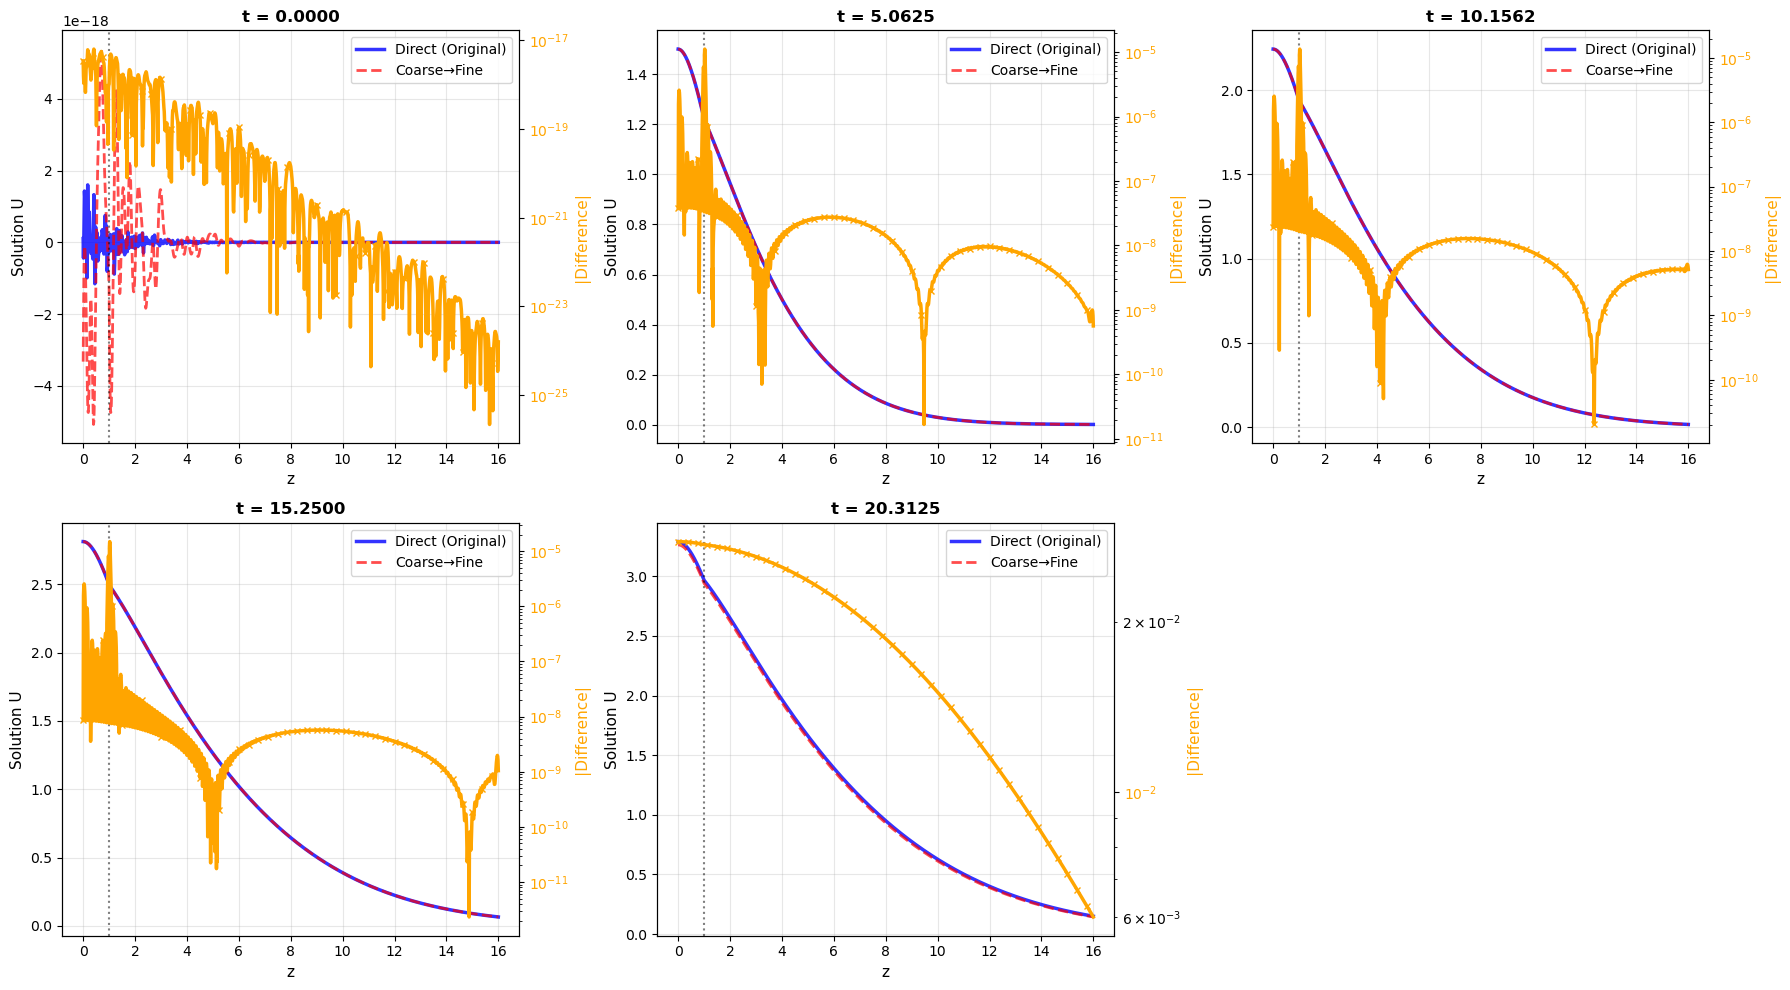

✓ Visualization saved: diagram_workflow_piecewise.png


In [11]:
# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

time_indices = [0, len(t_fine)//4, len(t_fine)//2, 3*len(t_fine)//4, len(t_fine)-1]

for ax_idx, t_idx in enumerate(time_indices):
    ax = axes[ax_idx]
    t_val = t_fine[t_idx]
    
    direct = U_fine_direct[:, t_idx]
    coarse_path = U_fine_coarse_path[:, t_idx]
    diff = err_diff[:, t_idx]
    
    # Solution comparison
    ax.plot(z_fine, direct, 'b-', linewidth=2.5, label='Direct (Original)', alpha=0.8)
    ax.plot(z_fine, coarse_path, 'r--', linewidth=2, label='Coarse→Fine', alpha=0.7)
    ax.axvline(z_dis, color='k', linestyle=':', linewidth=1.5, alpha=0.5)
    ax.set_xlabel('z', fontsize=11)
    ax.set_ylabel('Solution U', fontsize=11)
    ax.set_title(f't = {t_val:.4f}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    # Error on twin axis
    ax2 = ax.twinx()
    ax2.semilogy(z_fine, diff, 'orange', linewidth=2.5, label='|Difference|', marker='x', markersize=4, markevery=30)
    ax2.set_ylabel('|Difference|', fontsize=11, color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')

axes[-1].axis('off')

plt.tight_layout()
plt.savefig('diagram_workflow_piecewise.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: diagram_workflow_piecewise.png")

## Error Evolution Over Time

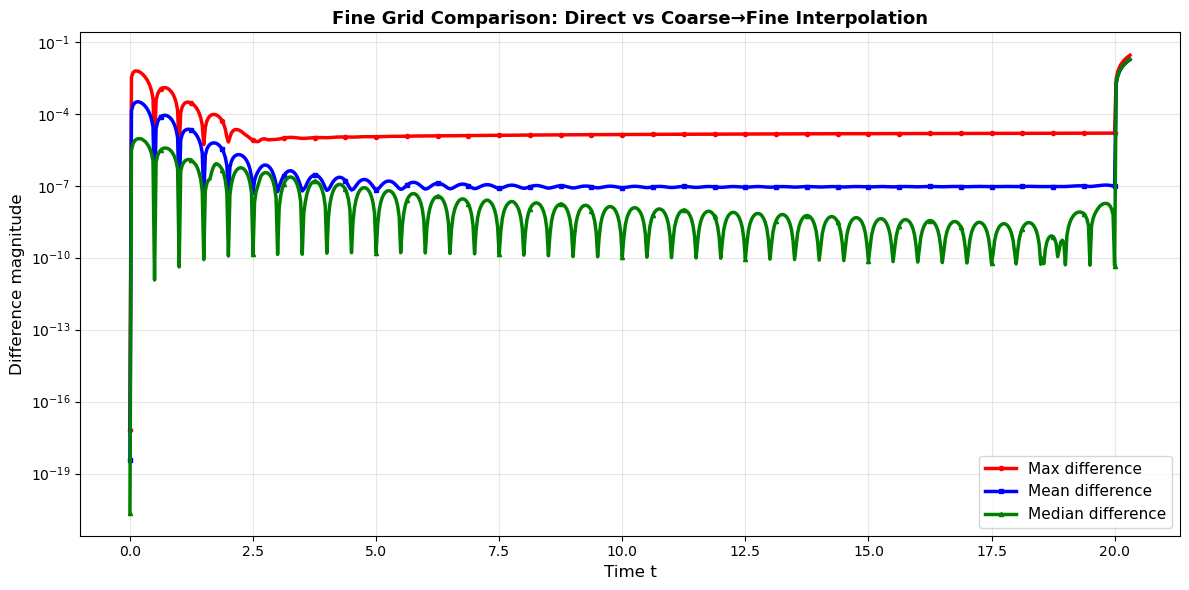

✓ Visualization saved: diagram_error_evolution.png


In [12]:
# Error evolution
max_diff_t = np.max(err_diff, axis=0)
mean_diff_t = np.mean(err_diff, axis=0)
median_diff_t = np.median(err_diff, axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(t_fine, max_diff_t, 'r-', linewidth=2.5, label='Max difference', marker='o', markersize=3, markevery=20)
ax.semilogy(t_fine, mean_diff_t, 'b-', linewidth=2.5, label='Mean difference', marker='s', markersize=3, markevery=20)
ax.semilogy(t_fine, median_diff_t, 'g-', linewidth=2.5, label='Median difference', marker='^', markersize=3, markevery=20)
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Difference magnitude', fontsize=12)
ax.set_title(f'Fine Grid Comparison: Direct vs Coarse→Fine Interpolation', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('diagram_error_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: diagram_error_evolution.png")

## 2D Heatmap: Error Distribution

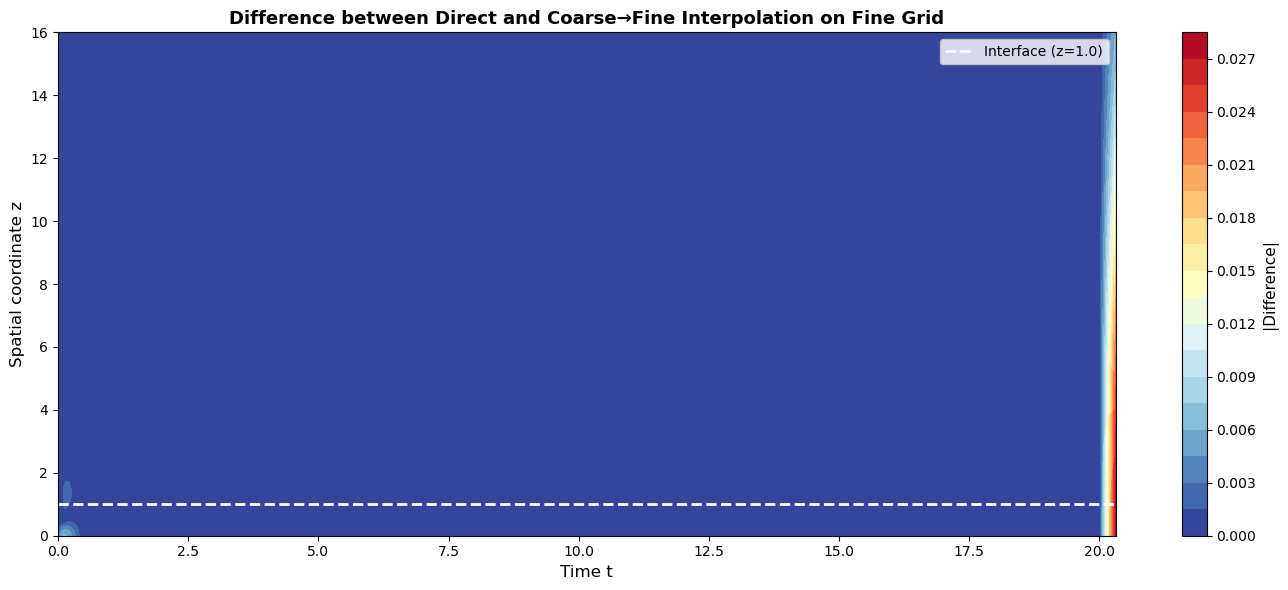

✓ Visualization saved: diagram_difference_heatmap.png

✓ All diagram workflow visualizations complete!


In [13]:
# 2D heatmap of difference
fig, ax = plt.subplots(figsize=(14, 6))
Z_fine_np, T_fine_np = np.meshgrid(z_fine, t_fine, indexing='ij')
contour = ax.contourf(T_fine_np, Z_fine_np, err_diff, levels=20, cmap='RdYlBu_r')
ax.axhline(z_dis, color='white', linestyle='--', linewidth=2, label=f'Interface (z={z_dis})')
ax.set_xlabel('Time t', fontsize=12)
ax.set_ylabel('Spatial coordinate z', fontsize=12)
ax.set_title(f'Difference between Direct and Coarse→Fine Interpolation on Fine Grid', fontsize=13, fontweight='bold')
cbar = plt.colorbar(contour, ax=ax)
cbar.set_label('|Difference|', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('diagram_difference_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: diagram_difference_heatmap.png")
print(f"\n✓ All diagram workflow visualizations complete!")